# Modeling

In [48]:
! pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 29.4 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=8e1f0564a58b1d33c83a5d648264b26709c05abc3302a22430a2e1c9fc61ecc6
  Stored in directory: c:\users\aleja\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking


In [49]:
# import the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import warnings
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

In [36]:
#Load the BTC Data
df = pd.read_csv("btc_15m_data_2018_to_2025.csv")
# Convertir la columna 'Open time' a datetime
df['Open time'] = pd.to_datetime(df['Open time'])
df.set_index('Open time', inplace=True)
print(df.head(5))

                         Open      High       Low     Close      Volume  \
Open time                                                                 
2018-01-01 00:00:00  13715.65  13715.65  13400.01  13556.15  123.616013   
2018-01-01 00:15:00  13533.75  13550.87  13402.00  13521.12   98.136430   
2018-01-01 00:30:00  13500.00  13545.37  13450.00  13470.41   79.904037   
2018-01-01 00:45:00  13494.65  13690.87  13450.00  13529.01  141.699719   
2018-01-01 01:00:00  13528.99  13571.74  13402.28  13445.63   72.537533   

                                      Close time  Quote asset volume  \
Open time                                                              
2018-01-01 00:00:00  2018-01-01 00:14:59.999000         1.675545e+06   
2018-01-01 00:15:00  2018-01-01 00:29:59.999000         1.321757e+06   
2018-01-01 00:30:00  2018-01-01 00:44:59.999000         1.078825e+06   
2018-01-01 00:45:00  2018-01-01 00:59:59.999000         1.917783e+06   
2018-01-01 01:00:00  2018-01-01 01:14:59.9

In [37]:
# Get only the close price
df = df[["Close"]].copy()
print(df.head(3))

                        Close
Open time                    
2018-01-01 00:00:00  13556.15
2018-01-01 00:15:00  13521.12
2018-01-01 00:30:00  13470.41


In [38]:
# Create a prediction column
forecast_days = 150*96
df["Prediction"] = df[["Close"]].shift(-forecast_days)
print(df.head(3))

                        Close  Prediction
Open time                                
2018-01-01 00:00:00  13556.15     7361.39
2018-01-01 00:15:00  13521.12     7399.99
2018-01-01 00:30:00  13470.41     7390.00


In [39]:
# Prepare the data
X = np.array(df.drop(["Prediction"], axis=1))[:-forecast_days]
Y = np.array(df["Prediction"])[:-forecast_days]

In [40]:
# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42)

In [41]:
# Create and train the model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [42]:
# Evaluate the model
preds = model.predict(X_test)
print ("MSE:", mean_squared_error(Y_test, preds))
print("R2:", r2_score(Y_test, preds))

MSE: 237702767.70138738
R2: 0.7781793809274407


In [43]:
# Predict the future prices
X_future = np.array(df.drop(["Prediction"], axis=1))[-forecast_days:]
future_predictions = model.predict(X_future)
print(future_predictions)

[75920.033   71280.3234  89704.647   ... 80106.88635 62492.9851
 77977.9773 ]


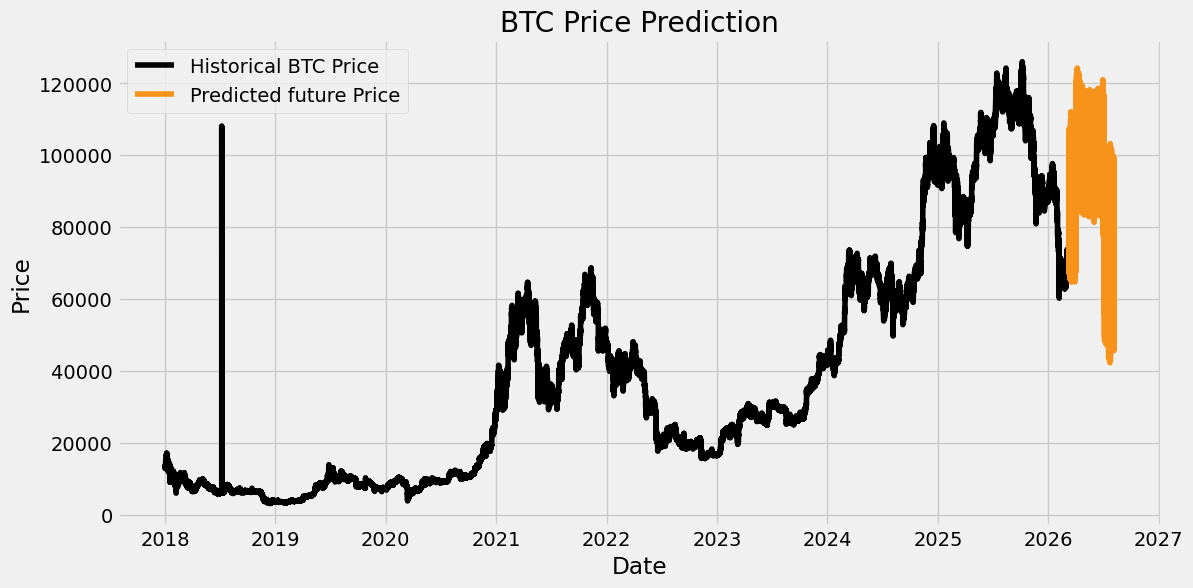

In [44]:
# Create a plot
last_date = df.index[-2]
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15),
                             periods=forecast_days,
                             freq='15min')

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label= "Historical BTC Price", color="black")
plt.plot(future_dates,future_predictions, 
         label="Predicted future Price", linestyle= "-" ,color="#F7931A")
plt.title("BTC Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.show()


In [45]:
outliers = df[(df.index.year == 2018) & (df['Close'] > 100000)]
print(outliers)

                         Close  Prediction
Open time                                 
2018-07-07 06:00:00  108115.55     3980.00
2018-07-07 06:15:00  108104.01     3978.41


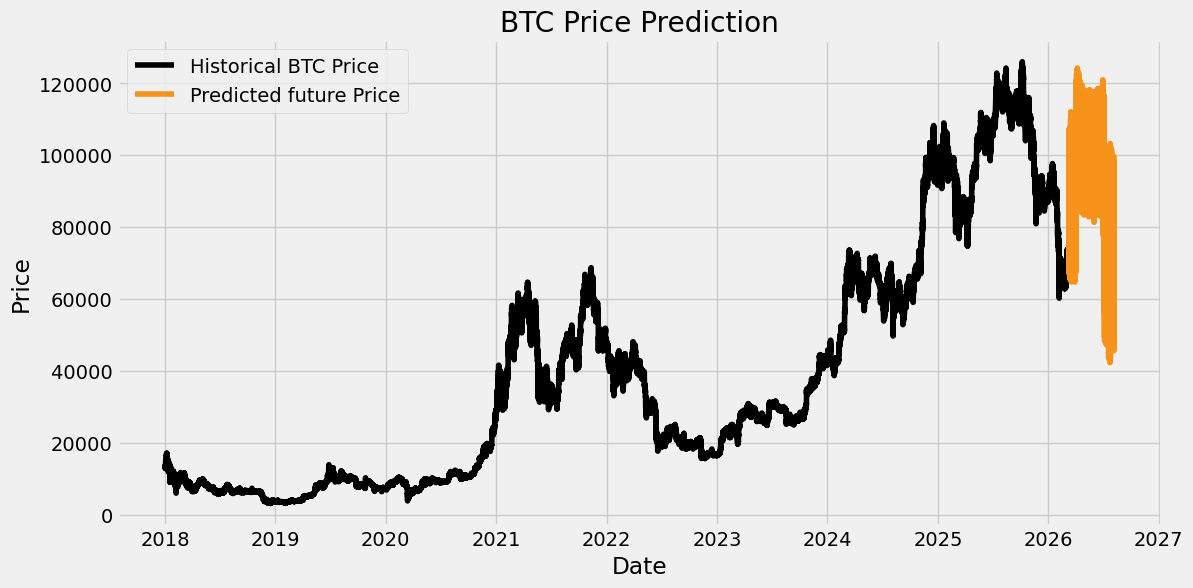

In [46]:
df = df.drop(pd.to_datetime([
    '2018-07-07 06:00:00', 
    '2018-07-07 06:15:00'
]))
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label= "Historical BTC Price", color="black")
plt.plot(future_dates,future_predictions, 
         label="Predicted future Price", linestyle= "-" ,color="#F7931A")
plt.title("BTC Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.show()

## Arima Prediction

In [81]:
# Ignore warnings
warnings.filterwarnings("ignore")
#Load the BTC Data
df_arima = pd.read_csv("btc_1d_data_2018_to_2025.csv")
df_arima["Open time"] = pd.to_datetime(df_arima["Open time"])
df_arima.set_index("Open time", inplace=True)
series = np.log(df_arima[["Close"]]).diff().dropna()
# Prepare train test split (80% train, 20% test)
end_date = df.index.max()
start_date = end_date - pd.DateOffset(days=90)

# Split train test
train_size = int(len(df_arima) * 0.8)

train = df_arima[:train_size]
test = df_arima[train_size:]

print(len(train), len(test))

2392 599


In [82]:
 # Step 2: ARIMA model tuning
p_values = range(0,4) 
d_values = range(0,2)
q_values = range(0,4)

def evaluate_arima_model(train, test, arima_order):
    try:
        model = ARIMA(train, order=arima_order)
        model_fit = model.fit()
        predictions = model_fit.forecast(steps=len(test))
        mse = mean_squared_error(test, predictions)
        return mse, model_fit
    except:
        return float("inf"), None

Best ARIMA: (1, 1, 2)
Best MSE: 932386124.4137689


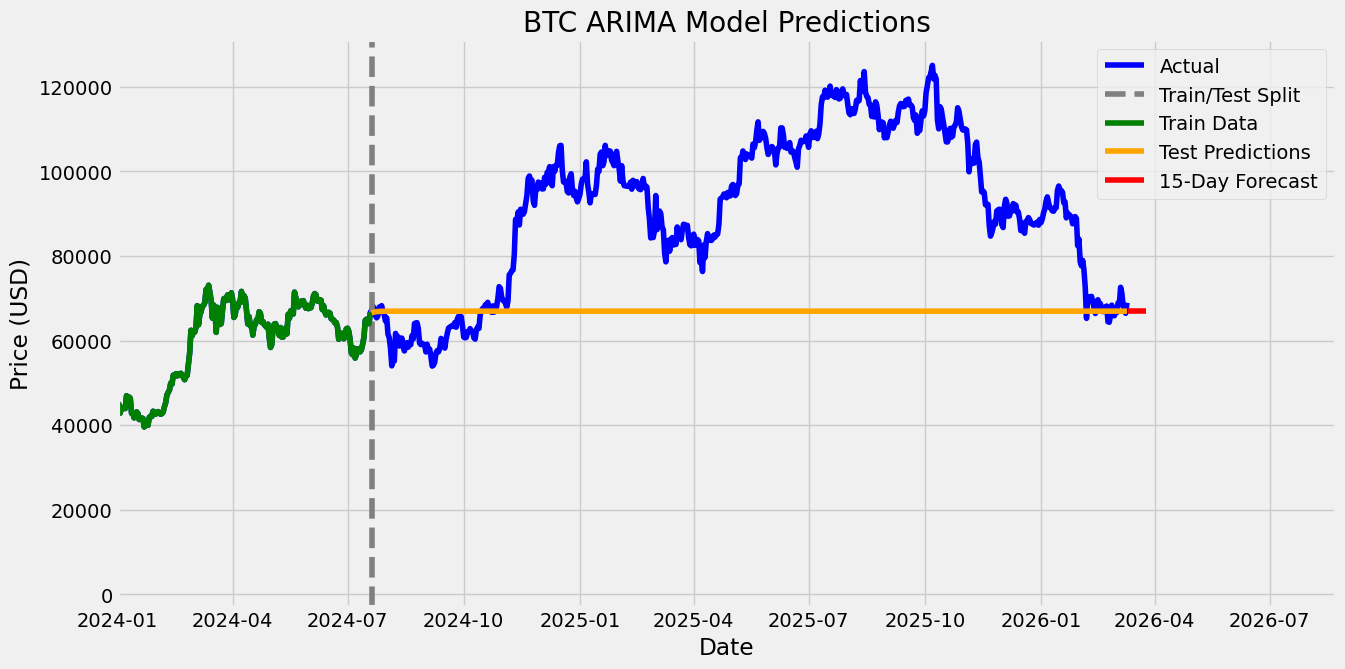

In [103]:
results = []
for p, d, q in product(p_values, d_values, q_values):
    arima_order = (p, d, q)
    mse, model_fit = evaluate_arima_model(train["Close"], test["Close"], arima_order)
    results.append((arima_order, mse, model_fit))
best_model = min(results, key=lambda x: x[1])

best_order = best_model[0]
best_mse = best_model[1]
best_fit = best_model[2]

print("Best ARIMA:", best_order)
print("Best MSE:", best_mse)
# Visualize each fit
forecast = best_fit.forecast(steps=len(test)+15)

plt.figure(figsize=(14,7))
plt.plot(df_arima.index, df_arima["Close"],label="Actual", color="blue")
plt.axvline(x=df_arima.index[train_size], color="gray", linestyle="--", 
            label="Train/Test Split")


plt.plot(train.index, train["Close"], label="Train Data", color="green")
plt.plot(test.index, forecast[:len(test)], label="Test Predictions",
        color="orange")

future_index = pd.date_range(start=test.index[-1], periods=16,
                             freq="D")[1:]
plt.plot(future_index, forecast[len(test):], label="15-Day Forecast",
         color="red")
plt.title("BTC ARIMA Model Predictions")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xlim(pd.Timestamp("2024-01-01"), None)
plt.legend()
plt.show()

In [84]:
naive_predictions = test["Close"].shift(1)
naive_predictions = naive_predictions.dropna()
test_naive = test["Close"].iloc[1:]
arima_predictions = best_fit.forecast(steps=len(test))

In [85]:
df_ml = df_arima.copy()

df_ml["lag1"] = df_ml["Close"].shift(1)
df_ml["lag2"] = df_ml["Close"].shift(2)
df_ml["lag3"] = df_ml["Close"].shift(3)

df_ml = df_ml.dropna()
X = df_ml[["lag1","lag2","lag3"]]
y = df_ml["Close"]
split = int(len(X)*0.8)

In [86]:
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [87]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [88]:
print("Naive RMSE:", np.sqrt(mean_squared_error(test_naive, naive_predictions)))

print("ARIMA RMSE:", np.sqrt(mean_squared_error(test["Close"], arima_predictions)))

print("RandomForest RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))

Naive RMSE: 2109.692570294787
ARIMA RMSE: 30534.99835293542
RandomForest RMSE: 28469.260739597135


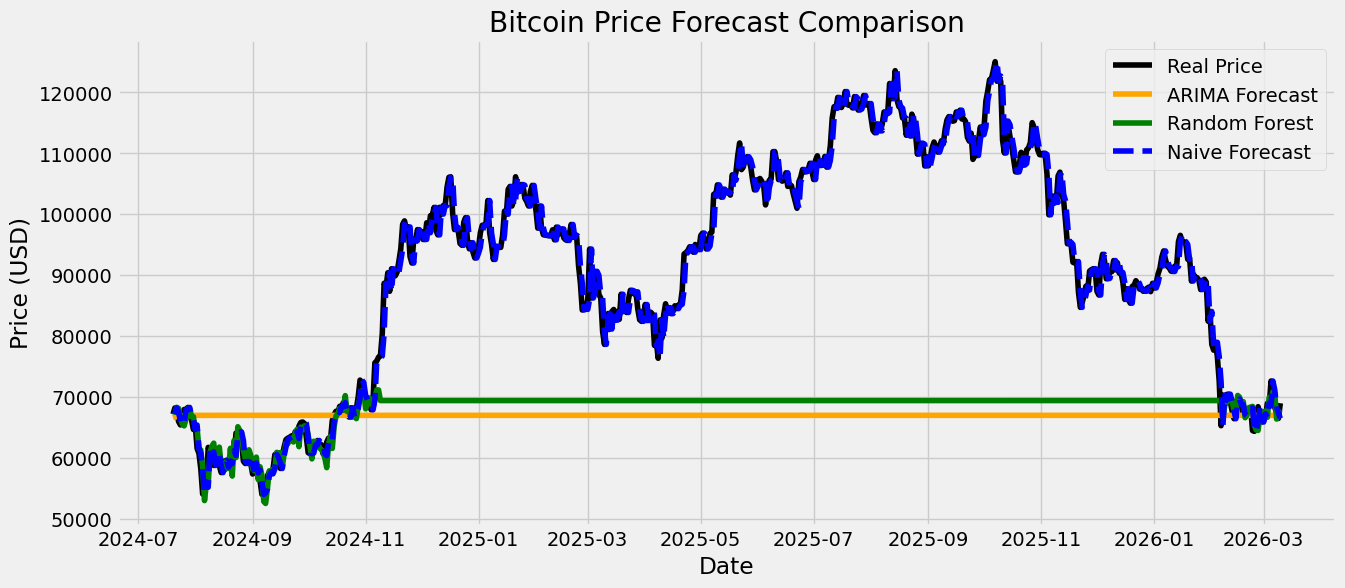

In [89]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test["Close"], label="Real Price", color="black")

plt.plot(test.index, arima_predictions,
         label="ARIMA Forecast", color="orange")

plt.plot(y_test.index, rf_predictions,
         label="Random Forest", color="green")

plt.plot(test_naive.index, naive_predictions,
         label="Naive Forecast", linestyle="dashed", color="blue")

plt.title("Bitcoin Price Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.show()

In [93]:
# Transformar a log returns
df_su = df_arima.copy()
df_su["log_return"] = np.log(df_su["Close"]).diff()
df_su = df_su.dropna()  # eliminar NaN de la primera fila

# Split train/test
train_size = int(len(df_su) * 0.8)
train_arima = df_su["log_return"][:train_size]
test_arima = df_su["log_return"][train_size:]

In [94]:
# Definir y entrenar modelo ARIMA simple (p,d,q)
p, d, q = 3, 0, 3  # ejemplo, ajustar según tuning
arima_model = ARIMA(train_arima, order=(p,d,q))
arima_fit = arima_model.fit()

# Predicción sobre test
arima_pred_returns = arima_fit.forecast(steps=len(test_arima))

# Reconstruir precios a partir del último precio conocido
last_train_price = df_su["Close"].iloc[train_size-1]
arima_pred_prices = last_train_price * np.exp(arima_pred_returns.cumsum())

In [95]:
# Crear features: últimos 3 cierres, volatilidad y volumen
df_rf = df_su.copy()
df_rf["lag1"] = df_rf["Close"].shift(1)
df_rf["lag2"] = df_rf["Close"].shift(2)
df_rf["lag3"] = df_rf["Close"].shift(3)
df_rf["volatility"] = df_rf["High"] - df_rf["Low"]
df_rf["volume"] = df_rf["Volume"]
df_rf = df_rf.dropna()

# Features y target
X = df_rf[["lag1","lag2","lag3","volatility","volume"]]
y = df_rf["Close"]

# Split train/test
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predicción
rf_pred = rf.predict(X_test)

In [96]:
# Precio de hoy = precio de mañana
naive_pred = y_test.shift(1).dropna()
y_test_naive = y_test.iloc[1:]
print("ARIMA RMSE:", np.sqrt(mean_squared_error(y_test, arima_pred_prices)))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Naive RMSE:", np.sqrt(mean_squared_error(y_test_naive, naive_pred)))

ARIMA RMSE: 19138.846827195273
Random Forest RMSE: 28435.378848215634
Naive RMSE: 2111.0416566614613


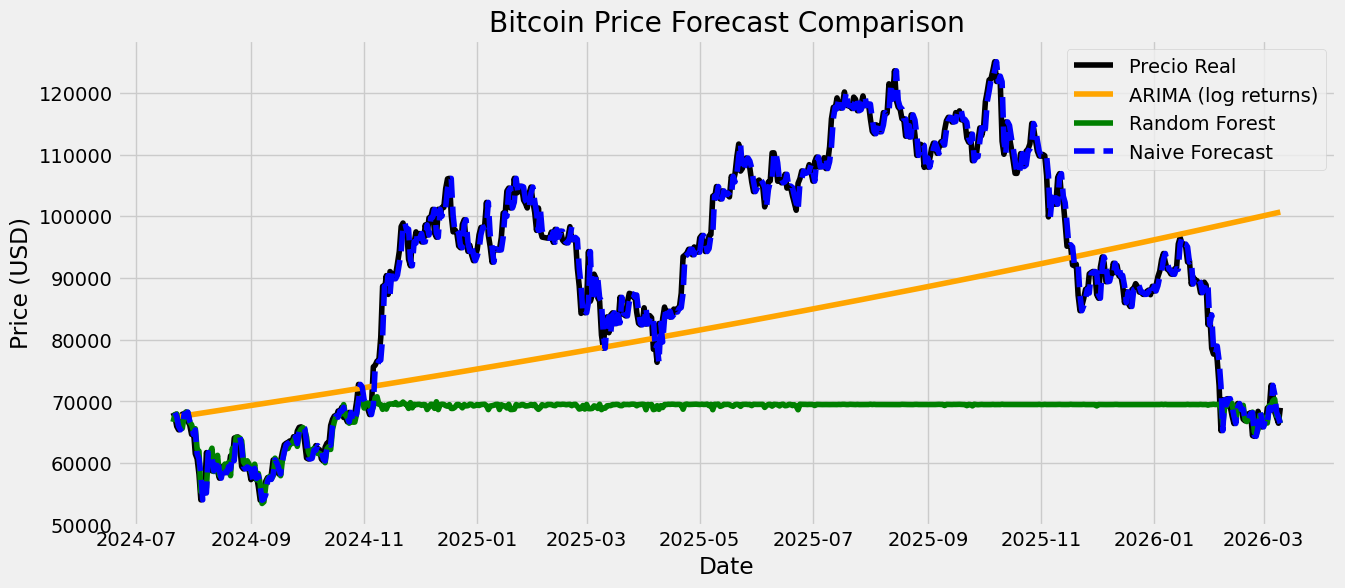

In [104]:
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test, label="Precio Real", color="black")
plt.plot(y_test.index, arima_pred_prices, label="ARIMA (log returns)", color="orange")
plt.plot(y_test.index, rf_pred, label="Random Forest", color="green")
plt.plot(y_test_naive.index, naive_pred, label="Naive Forecast", 
         linestyle="dashed", color="blue")

plt.title("Bitcoin Price Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()